In [2]:
import glob
import os
import site

# Must be set before importing tensorflow in this kernel.
nvidia_lib_dirs = []
for p in site.getsitepackages():
    nvidia_root = os.path.join(p, "nvidia")
    if os.path.isdir(nvidia_root):
        nvidia_lib_dirs.extend(glob.glob(os.path.join(nvidia_root, "*", "lib")))

current_ld = os.environ.get("LD_LIBRARY_PATH", "")
current_parts = [x for x in current_ld.split(":") if x]
required_parts = ["/usr/lib/wsl/lib"] + nvidia_lib_dirs
os.environ["LD_LIBRARY_PATH"] = ":".join(dict.fromkeys(required_parts + current_parts))

import tensorflow as tf

print("TF version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("GPUs:", tf.config.list_physical_devices("GPU"))

I0000 00:00:1774310232.603194    5651 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774310232.856599    5651 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774310234.532470    5651 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TF version: 2.21.0
Built with CUDA: True
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import tensorflow as tf
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt

In [4]:
data_path = "../"

X_train = np.load(data_path + 'X_train.npy')
Y_train = np.load(data_path + 'Y_train.npy')

X_val = np.load(data_path + 'X_val.npy')
Y_val = np.load(data_path + 'Y_val.npy')

X_test = np.load(data_path + 'X_test.npy')
Y_test = np.load(data_path + 'Y_test.npy')

print(f"Données chargées")
print(f"X_train shape: {X_train.shape}") 

Données chargées
X_train shape: (11990, 10, 28, 8, 2)


In [5]:
# Channel-wise standardization (real/imag normalized separately).
# Use stats from X_train, then reshape for X (5D) and Y (4D) to avoid broadcasting bugs.
mean_ch = np.mean(X_train, axis=(0, 1, 2, 3), keepdims=False)  # (2,)
std_ch = np.std(X_train, axis=(0, 1, 2, 3), keepdims=False)     # (2,)
std_ch = np.maximum(std_ch, 1e-6)

mean_x = mean_ch.reshape(1, 1, 1, 1, 2)
std_x = std_ch.reshape(1, 1, 1, 1, 2)
mean_y = mean_ch.reshape(1, 1, 1, 2)
std_y = std_ch.reshape(1, 1, 1, 2)

# Keep mean/std variable names for downstream cells.
mean = mean_y
std = std_y

def standardize_x(data):
    return (data - mean_x) / std_x

def standardize_y(data):
    return (data - mean_y) / std_y

X_train_scaled = standardize_x(X_train)
X_val_scaled = standardize_x(X_val)
X_test_scaled = standardize_x(X_test)

Y_train_scaled = standardize_y(Y_train)
Y_val_scaled = standardize_y(Y_val)
Y_test_scaled = standardize_y(Y_test)

print('Shapes after scaling:')
print('X_train_scaled:', X_train_scaled.shape)
print('Y_train_scaled:', Y_train_scaled.shape)
print('Channel stats (X_train_scaled):')
for c, name in enumerate(['real', 'imag']):
    c_mean = float(np.mean(X_train_scaled[..., c]))
    c_std = float(np.std(X_train_scaled[..., c]))
    print(f'  {name}: mean={c_mean:.4f}, std={c_std:.4f}')

Shapes after scaling:
X_train_scaled: (11990, 10, 28, 8, 2)
Y_train_scaled: (11990, 28, 8, 2)
Channel stats (X_train_scaled):
  real: mean=-0.0000, std=1.0324
  imag: mean=-0.0000, std=1.0328


In [6]:
def build_model_DiU_Backbone(seq_length=10):
    inputs = layers.Input(shape=(seq_length, 28, 8, 2))
    
    # 1. Temporal Encoder: ConvLSTM exactly as described for DiU backbone
    # 128 channels, 3x3 spatial kernel.
    lstm_out = layers.ConvLSTM2D(
        filters=128, kernel_size=(3, 3),
        padding='same', return_sequences=False
    )(inputs)
    # Output shape: (Batch, 28, 8, 128)
    
    # 2. U-Net Backbone spatial refinement (as the DiU diffusion generator)
    # Encoder block 1
    conv1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(lstm_out)
    conv1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(conv1)
    pool1 = layers.MaxPooling2D((2, 2))(conv1) # shape: (14, 4, 64)
    
    # Encoder block 2
    conv2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(pool1)
    conv2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(conv2)
    pool2 = layers.MaxPooling2D((2, 2))(conv2) # shape: (7, 2, 128)
    
    # Bottleneck
    conv3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(pool2)
    conv3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(conv3)
    
    # Decoder block 1
    up1 = layers.UpSampling2D((2, 2))(conv3) # shape: (14, 4, 256)
    up1 = layers.Conv2D(128, (2, 2), activation='relu', padding='same')(up1)
    concat1 = layers.Concatenate()([up1, conv2])
    conv4 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(concat1)
    conv4 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(conv4)
    
    # Decoder block 2
    up2 = layers.UpSampling2D((2, 2))(conv4) # shape: (28, 8, 128)
    up2 = layers.Conv2D(64, (2, 2), activation='relu', padding='same')(up2)
    concat2 = layers.Concatenate()([up2, conv1])
    conv5 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(concat2)
    conv5 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(conv5)
    
    # Final output projection
    outputs = layers.Conv2D(2, (3, 3), activation='linear', padding='same')(conv5)
    
    # Residual learning directly predicting the differential to the last snapshot
    last_snapshot = inputs[:, -1, :, :, :]
    outputs = layers.Add()([last_snapshot, outputs])
    
    return models.Model(inputs, outputs)

In [7]:
def nmse_metric(y_true, y_pred):
    mse = tf.reduce_sum(tf.square(y_true - y_pred), axis=[1, 2, 3])
    power = tf.reduce_sum(tf.square(y_true), axis=[1, 2, 3])
    return tf.reduce_mean(mse / (power + tf.keras.backend.epsilon()))

def hybrid_loss(y_true, y_pred):
    # NMSE keeps scale-invariant channel quality; MAE helps sharper spatial structure.
    nmse = nmse_metric(y_true, y_pred)
    mae = tf.reduce_mean(tf.abs(y_true - y_pred))
    return nmse + 0.05 * mae

In [8]:
early_stop = EarlyStopping(
    monitor='val_nmse_metric',
    mode='min',
    patience=12,
    min_delta=1e-4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_nmse_metric',
    mode='min',
    factor=0.5,
    patience=4,
    cooldown=1,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_diu_backbone_15k.keras',
    monitor='val_nmse_metric',
    mode='min',
    save_best_only=True,
    verbose=1
)

In [9]:
EPOCHS = 120
BATCH_SIZE = 32

model = build_model_DiU_Backbone(seq_length=10)

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=8e-4, weight_decay=1e-4, clipnorm=1.0),
    loss=hybrid_loss,
    metrics=[nmse_metric, 'mae']
)

history = model.fit(
    X_train_scaled, Y_train_scaled,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_scaled, Y_val_scaled),
    callbacks=[early_stop, reduce_lr, checkpoint],
    shuffle=True,
    verbose=1
)

I0000 00:00:1774310237.532927    5651 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Epoch 1/120


I0000 00:00:1774310242.749416   13926 service.cc:153] XLA service 0x7b2b7812fb70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774310242.749470   13926 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 13.1.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.10.2)
I0000 00:00:1774310242.882567   13926 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774310243.799124   13926 cuda_dnn.cc:461] Loaded cuDNN version 91002
I0000 00:00:1774310257.181557   13926 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 1.0722 - mae: 0.7727 - nmse_metric: 1.0336
Epoch 1: val_nmse_metric improved from None to 0.83832, saving model to best_diu_backbone_15k.keras

Epoch 1: finished saving model to best_diu_backbone_15k.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 49s 83ms/step - loss: 0.9443 - mae: 0.7320 - nmse_metric: 0.9076 - val_loss: 0.8725 - val_mae: 0.6914 - val_nmse_metric: 0.8383 - learning_rate: 8.0000e-04
Epoch 2/120
374/375 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.8581 - mae: 0.6959 - nmse_metric: 0.8233
Epoch 2: val_nmse_metric did not improve from 0.83832
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 44ms/step - loss: 0.8503 - mae: 0.6894 - nmse_metric: 0.8159 - val_loss: 0.8724 - val_mae: 0.6849 - val_nmse_metric: 0.8386 - learning_rate: 8.0000e-04
Epoch 3/120
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.8283 - mae: 0.6791 - nmse_metric: 0.7944
Epoch 3: val_nmse_metric improved from 0.83832 to 0.81341, saving model to best_diu_backbone_15k.keras

Epoch 

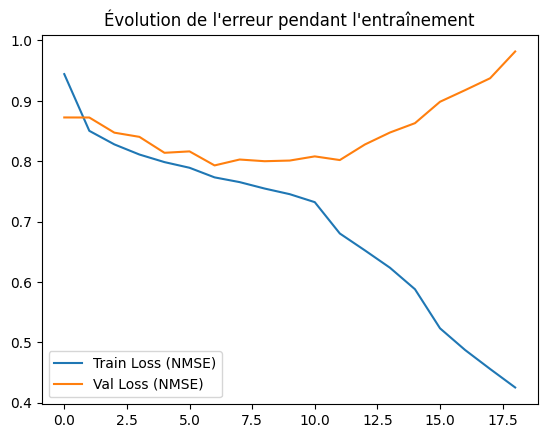

In [10]:

plt.plot(history.history['loss'], label='Train Loss (NMSE)')
plt.plot(history.history['val_loss'], label='Val Loss (NMSE)')
plt.title('Évolution de l\'erreur pendant l\'entraînement')
plt.legend()
plt.show()

--------------------------------------------------
RÉSULTATS SUR 50 ÉCHANTILLONS (Seuil: 2)
Similarité MOYENNE MODÈLE : 14.89%
Similarité MOYENNE NAÏVE  : 9.66%
Gain de l'IA (similarité) : 5.23%
NMSE MOYENNE MODÈLE (dB)  : -2.186
NMSE MOYENNE NAÏVE  (dB)  : 1.344
Gain NMSE (dB)            : 3.530 (plus grand = mieux)
--------------------------------------------------


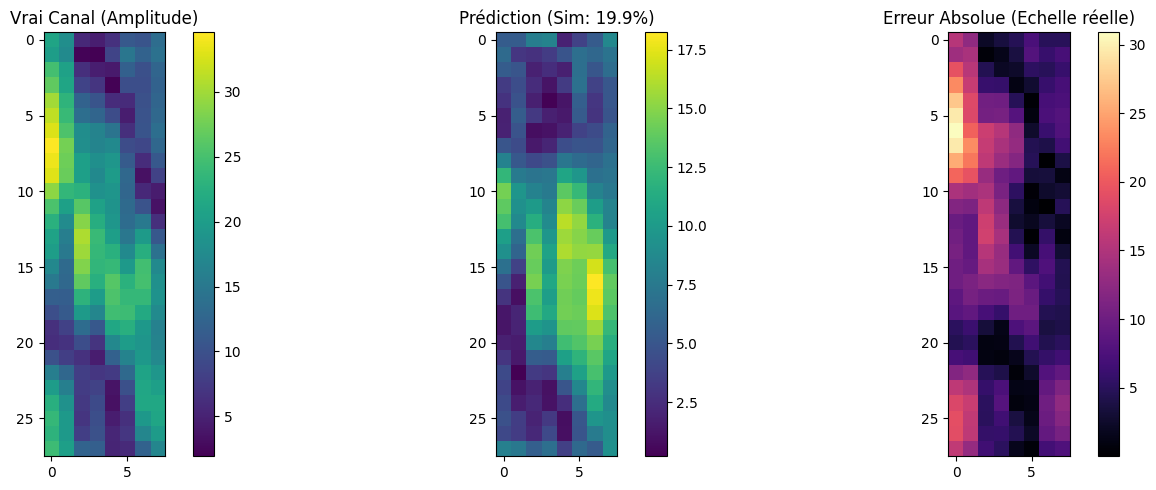

In [11]:
def evaluate_results(model, X_test_scaled, X_test_real, Y_test_real, mean, std, num_samples=100, tolerance=2):
    # 1. Prédire sur les données normalisées
    preds_norm = model.predict(X_test_scaled[:num_samples], verbose=0)

    # 2. DÉNORMALISATION de la prédiction
    preds_real = (preds_norm * std) + mean

    similarities_model = []
    similarities_naive = []

    # NMSE (dB) modèle et baseline naïve
    nmse_db_model = []
    nmse_db_naive = []

    for i in range(num_samples):
        # --- Calcul Similarité Modèle ---
        diff_model = np.abs(Y_test_real[i] - preds_real[i])
        acc_m = np.mean(diff_model < tolerance) * 100
        similarities_model.append(acc_m)

        # --- Calcul Similarité Naïve (Persistance) ---
        naive_snapshot = X_test_real[i, -1, :, :, :]
        diff_naive = np.abs(Y_test_real[i] - naive_snapshot)
        acc_n = np.mean(diff_naive < tolerance) * 100
        similarities_naive.append(acc_n)

        # --- NMSE dB (modèle / naïf) ---
        eps = 1e-12
        den = np.sum(np.square(Y_test_real[i])) + eps

        nmse_m = np.sum(np.square(Y_test_real[i] - preds_real[i])) / den
        nmse_n = np.sum(np.square(Y_test_real[i] - naive_snapshot)) / den

        nmse_db_model.append(10.0 * np.log10(nmse_m + eps))
        nmse_db_naive.append(10.0 * np.log10(nmse_n + eps))

    # --- Affichage des Scores ---
    avg_model = np.mean(similarities_model)
    avg_naive = np.mean(similarities_naive)

    avg_nmse_model = np.mean(nmse_db_model)
    avg_nmse_naive = np.mean(nmse_db_naive)

    print("-" * 50)
    print(f"RÉSULTATS SUR {num_samples} ÉCHANTILLONS (Seuil: {tolerance})")
    print(f"Similarité MOYENNE MODÈLE : {avg_model:.2f}%")
    print(f"Similarité MOYENNE NAÏVE  : {avg_naive:.2f}%")
    print(f"Gain de l'IA (similarité) : {avg_model - avg_naive:.2f}%")
    print(f"NMSE MOYENNE MODÈLE (dB)  : {avg_nmse_model:.3f}")
    print(f"NMSE MOYENNE NAÏVE  (dB)  : {avg_nmse_naive:.3f}")
    print(f"Gain NMSE (dB)            : {avg_nmse_naive - avg_nmse_model:.3f} (plus grand = mieux)")
    print("-" * 50)

    # --- Visualisation du dernier échantillon ---
    idx = num_samples - 1
    true_amp = np.sqrt(Y_test_real[idx, ..., 0]**2 + Y_test_real[idx, ..., 1]**2)
    pred_amp = np.sqrt(preds_real[idx, ..., 0]**2 + preds_real[idx, ..., 1]**2)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.title("Vrai Canal (Amplitude)")
    plt.imshow(true_amp, cmap='viridis')
    plt.colorbar()

    plt.subplot(1, 3, 2)
    plt.title(f"Prédiction (Sim: {similarities_model[-1]:.1f}%)")
    plt.imshow(pred_amp, cmap='viridis')
    plt.colorbar()

    plt.subplot(1, 3, 3)
    plt.title("Erreur Absolue (Echelle réelle)")
    plt.imshow(np.abs(true_amp - pred_amp), cmap='magma')
    plt.colorbar()

    plt.tight_layout()
    plt.show()

    return preds_real

pred = evaluate_results(model, X_test_scaled, X_test, Y_test, mean, std, num_samples=50, tolerance=2)

In [12]:
import numpy as np

print('Shapes:')
print('X_train:', X_train.shape, 'Y_train:', Y_train.shape)
print('X_val  :', X_val.shape, 'Y_val  :', Y_val.shape)
print('X_test :', X_test.shape, 'Y_test :', Y_test.shape)

print('\nScale stats (real domain):')
print('X_train min/max:', float(np.min(X_train)), float(np.max(X_train)))
print('Y_train min/max:', float(np.min(Y_train)), float(np.max(Y_train)))
print('mean used for standardization (real, imag):', np.squeeze(mean).tolist())
print('std used for standardization  (real, imag):', np.squeeze(std).tolist())

print('\nScale stats (normalized):')
print('X_train_scaled min/max:', float(np.min(X_train_scaled)), float(np.max(X_train_scaled)))
print('Y_train_scaled min/max:', float(np.min(Y_train_scaled)), float(np.max(Y_train_scaled)))

if 'history' in globals():
    train_loss = history.history.get('loss', [])
    val_loss = history.history.get('val_loss', [])
    train_nmse = history.history.get('nmse_metric', [])
    val_nmse = history.history.get('val_nmse_metric', [])

    if train_loss and val_loss:
        print('\nLoss summary:')
        print('train first/last/min:', float(train_loss[0]), float(train_loss[-1]), float(np.min(train_loss)))
        print('val   first/last/min:', float(val_loss[0]), float(val_loss[-1]), float(np.min(val_loss)))
        print('best val-loss epoch (1-based):', int(np.argmin(val_loss) + 1))

    if train_nmse and val_nmse:
        print('\nNMSE summary:')
        print('train first/last/min:', float(train_nmse[0]), float(train_nmse[-1]), float(np.min(train_nmse)))
        print('val   first/last/min:', float(val_nmse[0]), float(val_nmse[-1]), float(np.min(val_nmse)))
        print('best val-NMSE epoch (1-based):', int(np.argmin(val_nmse) + 1))

# Naive baseline on standardized target (same domain as training objective)
naive_pred = X_test_scaled[:, -1, :, :, :]
mse = np.mean((naive_pred - Y_test_scaled) ** 2, axis=(1,2,3))
power = np.mean((Y_test_scaled) ** 2, axis=(1,2,3)) + 1e-12
nmse = mse / power
print('\nNaive baseline NMSE on test (normalized domain):', float(np.mean(nmse)))

# Compare model vs naive with your similarity metric on real domain
num = 300
preds_norm = model.predict(X_test_scaled[:num], verbose=0)
preds_real = preds_norm * std + mean
naive_real = X_test[:num, -1, :, :, :]
true_real = Y_test[:num]

for tol in [0.1, 0.5, 1.0, 2.0]:
    sim_model = np.mean(np.abs(true_real - preds_real) < tol) * 100.0
    sim_naive = np.mean(np.abs(true_real - naive_real) < tol) * 100.0
    print(f'tol={tol:<4} model={sim_model:6.3f}% | naive={sim_naive:6.3f}% | gain={sim_model-sim_naive:6.3f}%')

Shapes:
X_train: (11990, 10, 28, 8, 2) Y_train: (11990, 28, 8, 2)
X_val  : (1490, 10, 28, 8, 2) Y_val  : (1490, 28, 8, 2)
X_test : (1490, 10, 28, 8, 2) Y_test : (1490, 28, 8, 2)

Scale stats (real domain):
X_train min/max: -74.62322998046875 77.62633514404297
Y_train min/max: -74.62322998046875 77.62633514404297
mean used for standardization (real, imag): [0.017035722732543945, -0.2411108911037445]
std used for standardization  (real, imag): [15.677179336547852, 15.560371398925781]

Scale stats (normalized):
X_train_scaled min/max: -4.761077404022217 4.95046329498291
Y_train_scaled min/max: -4.761077404022217 4.95046329498291

Loss summary:
train first/last/min: 0.944320559501648 0.42531853914260864 0.42531853914260864
val   first/last/min: 0.8725224733352661 0.9817907810211182 0.7930800318717957
best val-loss epoch (1-based): 7

NMSE summary:
train first/last/min: 0.9075829982757568 0.401166170835495 0.401166170835495
val   first/last/min: 0.838316023349762 0.9471953511238098 0.760556

In [13]:
import numpy as np

print('=== Compact diagnostics ===')
print('Shapes:', X_train.shape, Y_train.shape, X_val.shape, Y_val.shape, X_test.shape, Y_test.shape)

if 'history' in globals():
    tr = np.array(history.history.get('loss', []), dtype=float)
    va = np.array(history.history.get('val_loss', []), dtype=float)
    if tr.size and va.size:
        best = int(np.argmin(va))
        print(f'Best epoch: {best+1}/{len(va)}')
        print(f'Train loss best/last: {tr.min():.6f} / {tr[-1]:.6f}')
        print(f'Val   loss best/last: {va.min():.6f} / {va[-1]:.6f}')
        print(f'Generalization gap at best epoch: {va[best]-tr[best]:.6f}')

# Baselines in normalized domain
naive_test = X_test_scaled[:, -1, :, :, :]
naive_nmse = np.mean(np.sum((naive_test - Y_test_scaled) ** 2, axis=(1,2,3)) /
                     (np.sum((Y_test_scaled) ** 2, axis=(1,2,3)) + 1e-12))
print(f'Naive persistence NMSE (normalized): {naive_nmse:.6f}')

# Model test NMSE (normalized)
preds_test_norm = model.predict(X_test_scaled, batch_size=256, verbose=0)
model_nmse = np.mean(np.sum((preds_test_norm - Y_test_scaled) ** 2, axis=(1,2,3)) /
                     (np.sum((Y_test_scaled) ** 2, axis=(1,2,3)) + 1e-12))
print(f'Model NMSE (normalized): {model_nmse:.6f}')
print(f'NMSE improvement vs naive: {(naive_nmse-model_nmse):.6f} ({100*(naive_nmse-model_nmse)/(naive_nmse+1e-12):.2f}%)')

# Similarity comparison in real domain on a subset for speed
num = min(1000, X_test_scaled.shape[0])
preds_real = preds_test_norm[:num] * std + mean
true_real = Y_test[:num]
naive_real = X_test[:num, -1, :, :, :]
for tol in [0.1, 0.5, 1.0, 2.0]:
    sim_model = np.mean(np.abs(true_real - preds_real) < tol) * 100.0
    sim_naive = np.mean(np.abs(true_real - naive_real) < tol) * 100.0
    print(f'tol={tol:<3} model={sim_model:6.2f}% naive={sim_naive:6.2f}% gain={sim_model-sim_naive:6.2f}%')

=== Compact diagnostics ===
Shapes: (11990, 10, 28, 8, 2) (11990, 28, 8, 2) (1490, 10, 28, 8, 2) (1490, 28, 8, 2) (1490, 10, 28, 8, 2) (1490, 28, 8, 2)
Best epoch: 7/19
Train loss best/last: 0.425319 / 0.425319
Val   loss best/last: 0.793080 / 0.981791
Generalization gap at best epoch: 0.019804
Naive persistence NMSE (normalized): 1.622305
Model NMSE (normalized): 0.746076
NMSE improvement vs naive: 0.876229 (54.01%)
tol=0.1 model=  0.71% naive=  0.45% gain=  0.26%
tol=0.5 model=  3.53% naive=  2.21% gain=  1.33%
tol=1.0 model=  7.11% naive=  4.46% gain=  2.65%
tol=2.0 model= 14.20% naive=  8.94% gain=  5.26%


In [14]:
# Quick sanity check: cardinality and one short fit step
print('Cardinality check:', X_train_scaled.shape[0], Y_train_scaled.shape[0])

model_sanity = build_model_DiU_Backbone(seq_length=10)
model_sanity.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=8e-4, weight_decay=1e-4, clipnorm=1.0),
    loss=hybrid_loss,
    metrics=[nmse_metric, 'mae']
)

sanity_hist = model_sanity.fit(
    X_train_scaled[:128], Y_train_scaled[:128],
    validation_data=(X_val_scaled[:64], Y_val_scaled[:64]),
    epochs=1,
    batch_size=32,
    verbose=1
)
print('Sanity fit OK. train_loss=', float(sanity_hist.history['loss'][-1]))

Cardinality check: 11990 11990
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 492ms/step - loss: 1.9655 - mae: 0.9390 - nmse_metric: 1.9185 - val_loss: 1.6706 - val_mae: 0.9214 - val_nmse_metric: 1.6245
Sanity fit OK. train_loss= 1.9654858112335205
